In [4]:
# -*- coding: utf-8 -*-
# Upgrade: age-banded Big Five normals, fixed cohort sizes, youth-football context
# Notes:
# - Keeps prior structure and functions, adds age-aware sampling and quotas.
# - Age groups: 7–10 (pre-puberty), 11–14 (in-puberty), 15–18 (post-puberty for this cohort).
# - Cohort sizes: 500, 350, 150 (total 1,000).

import json
import numpy as np
import random

# =========================
# CONFIG
# =========================

# Age group definitions and cohort targets
AGE_GROUPS = {
    "7-10": {"min_age": 7, "max_age": 10, "target": 500},
    "11-14": {"min_age": 11, "max_age": 14, "target": 350},
    "15-18": {"min_age": 15, "max_age": 18, "target": 150},
}

# Big Five distributions by age band (mean, sd) on 0–100 scale
# Rationale (high level):
# - Conscientiousness: lower in preteens, rises in later adolescence.
# - Neuroticism: higher during early/mid adolescence, then tapers down.
# - Agreeableness: modest dip mid-teens, rebounds later.
# - Extraversion and Openness: modestly higher in sport-engaged youth vs. general peers.
# SDs kept similar across bands to reflect individual variability; small tweaks for mid-teen volatility.
BIG_FIVE_BY_AGE = {
    "7-10": {
        "openness":        (56, 15),
        "conscientiousness": (57, 14),
        "extraversion":    (66, 18),
        "agreeableness":   (69, 12),
        "neuroticism":     (43, 18),
    },
    "11-14": {
        "openness":        (57, 15),
        "conscientiousness": (59, 15),
        "extraversion":    (67, 18),
        "agreeableness":   (66, 12),
        "neuroticism":     (50, 18),
    },
    "15-18": {
        "openness":        (58, 15),
        "conscientiousness": (62, 14),
        "extraversion":    (65, 17),
        "agreeableness":   (68, 11),
        "neuroticism":     (46, 17),
    },
}

# Base weights for satisfaction model (unchanged)
BASE_WEIGHTS = {
    "extraversion": 0.18,
    "agreeableness": 0.12,
    "conscientiousness": 0.15,
    "openness": 0.06,
    "neuroticism": -0.30
}

# Trait correlations for light post-processing (unchanged)
correlation = {
    "extraversion": {"agreeableness": 0.2, "neuroticism": -0.25},
    "conscientiousness": {"neuroticism": -0.4, "agreeableness": 0.15},
    "agreeableness": {"conscientiousness": 0.2, "neuroticism": -0.1},
    "openness": {"extraversion": 0.15}
}

# =========================
# UTILS
# =========================
def clamp(x, min_val=0, max_val=100):
    return max(min_val, min(max_val, x))

def sample_trait(mean, std):
    return int(clamp(np.random.normal(mean, std)))

def sample_age_for_group(group_key):
    g = AGE_GROUPS[group_key]
    return random.randint(g["min_age"], g["max_age"])

def infer_group_from_age(age):
    if 7 <= age <= 10:
        return "7-10"
    if 11 <= age <= 14:
        return "11-14"
    return "15-18"

# =========================
# EMOTION
# =========================
def sample_emotional_state():
    outcomes = ["win", "loss", "draw"]
    results = [random.choices(outcomes, weights=[0.5, 0.3, 0.2])[0] for _ in range(5)]
    wins = results.count("win")
    losses = results.count("loss")

    win_rate = wins / 5
    loss_rate = losses / 5

    if win_rate >= 0.6:
        recent_event = "won_match"
    elif loss_rate >= 0.6:
        recent_event = "lost_match"
    else:
        recent_event = "none"

    mood_score = 0
    if win_rate >= 0.6:
        mood_score += 20
    elif win_rate >= 0.4:
        mood_score += 5

    if loss_rate >= 0.6:
        mood_score -= 20
    elif loss_rate >= 0.4:
        mood_score -= 5

    if mood_score >= 10:
        current_mood = "excited"
    elif mood_score >= 5:
        current_mood = "happy"
    elif mood_score <= -10:
        current_mood = "frustrated"
    elif mood_score <= -5:
        current_mood = "anxious"
    else:
        current_mood = "neutral"

    stress_level = 50
    stress_level += loss_rate * 40
    stress_level -= win_rate * 30
    stress_level += random.randint(-10, 10)

    return {
        "recent_results": results,
        "current_mood": current_mood,
        "recent_event": recent_event,
        "stress_level": int(clamp(stress_level))
    }

# =========================
# CONTEXT SAMPLING (slight sports-aware tweaks)
# =========================
def sample_team_context(group_key):
    # Map age band to common youth football brackets
    if group_key == "7-10":
        age_group_team = random.choices(["U7", "U8", "U9", "U10"], weights=[0.2, 0.3, 0.3, 0.2])[0]
    elif group_key == "11-14":
        age_group_team = random.choices(["U11", "U12", "U13", "U14"], weights=[0.25, 0.25, 0.25, 0.25])[0]
    else:
        age_group_team = random.choices(["U15", "U16", "U17", "U18"], weights=[0.25, 0.25, 0.25, 0.25])[0]

    return {
        "age_group_team": age_group_team,
        "position": random.choice(["goalkeeper", "defender", "midfielder", "forward", "mixed"]),
        "playing_time": random.choices(["low", "medium", "high"], weights=[0.25, 0.55, 0.20])[0],
        "skill_level": random.choices(["low", "medium", "high"], weights=[0.30, 0.50, 0.20])[0],
    }

def sample_social_context():
    return {
        "coach_relationship": random.choices(["bad", "neutral", "good"], weights=[0.1, 0.35, 0.55])[0],
        "teammate_relationship": random.choices(["isolated", "average", "strong"], weights=[0.18, 0.52, 0.30])[0],
        "peer_influence": random.choice(["low", "medium", "high"]),
        "bullying_experience": random.choices(["none", "mild", "frequent"], weights=[0.65, 0.28, 0.07])[0],
        "friendship_importance": random.choices(["low", "medium", "high"], weights=[0.1, 0.35, 0.55])[0],
    }

# =========================
# BIG 5 SAMPLING + ADJUSTMENT
# =========================
def sample_big_five_for_group(group_key):
    cfg = BIG_FIVE_BY_AGE[group_key]
    return {trait: sample_trait(mean, sd) for trait, (mean, sd) in cfg.items()}

def adjust_big_five(traits):
    # small noise
    for k in traits:
        traits[k] += random.randint(-2, 2)

    # correlations
    for src, targets in correlation.items():
        for tgt, weight in targets.items():
            traits[tgt] += traits[src] * weight * 0.05

    # domain-specific nudges (light, same as before)
    traits["neuroticism"] -= traits["conscientiousness"] * 0.03
    traits["agreeableness"] += traits["extraversion"] * 0.02
    traits["extraversion"] += traits["openness"] * 0.01

    return {k: int(clamp(v)) for k, v in traits.items()}

# =========================
# SATISFACTION MODEL
# =========================
def compute_satisfaction(persona):
    base = 50

    team = persona["team_context"]
    social = persona["social_context"]
    family = persona["family_context"]
    big5 = persona["psychology_big_five"]
    emo = persona["emotional_state"]

    # TEAM
    if team["playing_time"] == "high":
        base += 18
    elif team["playing_time"] == "low":
        base -= 10

    if team["skill_level"] == "high":
        base += 10

    # SOCIAL
    if social["coach_relationship"] == "good":
        base += 15
    elif social["coach_relationship"] == "bad":
        base -= 20

    if social["teammate_relationship"] == "strong":
        base += 12
    elif social["teammate_relationship"] == "isolated":
        base -= 15

    if social["bullying_experience"] == "frequent":
        base -= 25

    # FAMILY
    if family["parent_support"] == "high":
        base += 12
    elif family["parent_support"] == "low":
        base -= 12

    if family["parent_pressure"] == "high":
        base -= 15

    # BIG 5
    for trait, weight in BASE_WEIGHTS.items():
        base += (big5[trait] - 50) * weight

    # EMOTION
    mood_map = {
        "happy": 10,
        "excited": 12,
        "neutral": 0,
        "frustrated": -10,
        "anxious": -8
    }

    base += mood_map.get(emo["current_mood"], 0)
    base -= emo["stress_level"] * 0.2

     # AGE-BAND SATISFACTION EFFECT
    age = persona["identity"]["age"]
    age_group = infer_group_from_age(age)

    if age_group == "15-18":
        base -= 12

    return int(clamp(base))

# =========================
# PERSONA GENERATION
# =========================
def generate_persona(idx, group_key):
    age = sample_age_for_group(group_key)

    persona = {
        "persona_id": f"child_{idx}",
        "identity": {
            "age": age,
            "country": "Germany",
            "team_role": "player"
        },
        "team_context": sample_team_context(group_key),
        "social_context": sample_social_context(),
        "family_context": {
            "parent_support": random.choice(["low", "medium", "high"]),
            "parent_pressure": random.choice(["low", "medium", "high"]),
            "sports_expectation": random.choice(["fun", "balanced", "performance_focused"])
        },
        "psychology_big_five": sample_big_five_for_group(group_key),
        "emotional_state": sample_emotional_state()
    }

    # apply correlation/adjustment
    persona["psychology_big_five"] = adjust_big_five(persona["psychology_big_five"])
    # satisfaction
    persona["satisfaction"] = compute_satisfaction(persona)
    return persona

def generate_population_by_quota():
    population = []
    idx = 0
    for gk, meta in AGE_GROUPS.items():
        for _ in range(meta["target"]):
            population.append(generate_persona(idx, gk))
            idx += 1
    return population

# =========================
# RUN
# =========================
if __name__ == "__main__":
    population = generate_population_by_quota()
    with open("personas2.json", "w") as f:
        json.dump(population, f, indent=2, ensure_ascii=False)


# Visualisierung

            openness  conscientiousness  extraversion  agreeableness  \
age_group                                                              
7-10       55.024000          56.400000     65.732000      70.170000   
11-14      56.791429          58.614286     65.545714      68.237143   
15-18      58.340000          61.680000     64.060000      68.226667   

           neuroticism  
age_group               
7-10         37.114000  
11-14        44.991429  
15-18        38.113333  


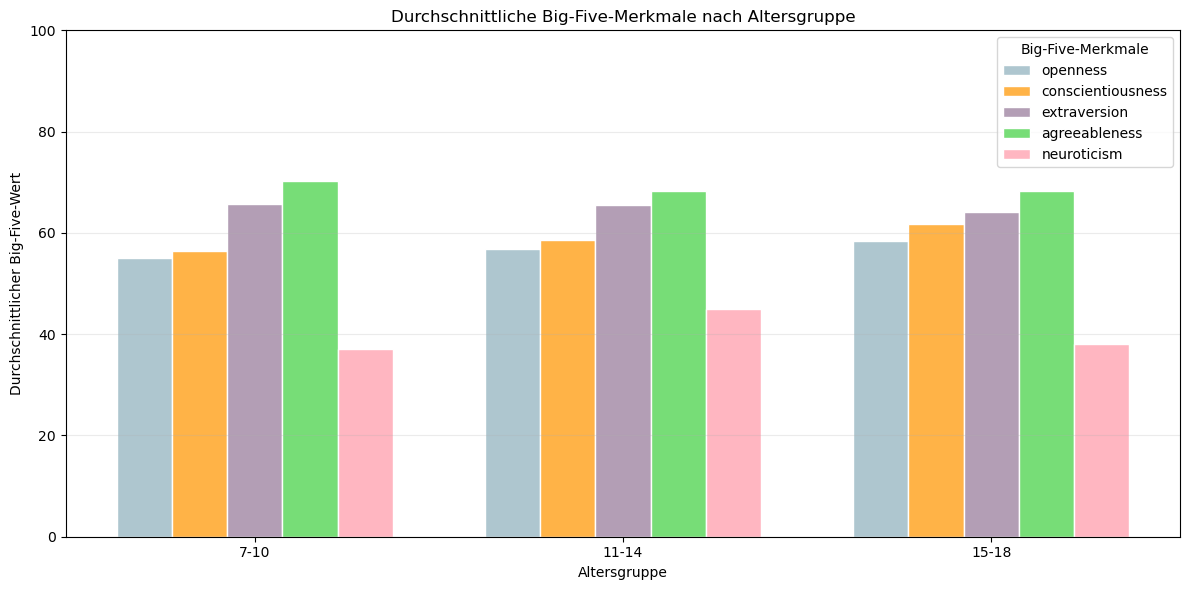

In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Daten laden
with open("personas2.json", "r", encoding="utf-8") as f:
    population = json.load(f)

# 2. JSON-Daten in eine flache Tabellenstruktur umwandeln
rows = []

for p in population:
    age = p["identity"]["age"]

    # Altersgruppe bestimmen
    if 7 <= age <= 10:
        age_group = "7-10"
    elif 11 <= age <= 14:
        age_group = "11-14"
    else:
        age_group = "15-18"

    # Big-Five-Werte auslesen
    big5 = p["psychology_big_five"]

    rows.append({
        "age_group": age_group,
        "openness": big5["openness"],
        "conscientiousness": big5["conscientiousness"],
        "extraversion": big5["extraversion"],
        "agreeableness": big5["agreeableness"],
        "neuroticism": big5["neuroticism"]
    })

df = pd.DataFrame(rows)

# 3. Big-Five-Merkmale definieren
traits = [
    "openness",
    "conscientiousness",
    "extraversion",
    "agreeableness",
    "neuroticism"
]

# 4. Durchschnittswerte pro Altersgruppe berechnen
mean_by_age_group = df.groupby("age_group")[traits].mean()

# Reihenfolge der Altersgruppen festlegen
mean_by_age_group = mean_by_age_group.loc[["7-10", "11-14", "15-18"]]

print(mean_by_age_group)

# 5. Pastellfarben für die fünf Big-Five-Merkmale
pastel_colors = {
    "openness": "#AEC6CF",             # Pastellblau
    "conscientiousness": "#FFB347",    # Pastellorange
    "extraversion": "#B39EB5",         # Pastellviolett
    "agreeableness": "#77DD77",        # Pastellgrün
    "neuroticism": "#FFB6C1"           # Pastellrosa
}

# 6. Grouped Bar Chart erstellen
x = np.arange(len(mean_by_age_group.index))
width = 0.15

plt.figure(figsize=(12, 6))

for i, trait in enumerate(traits):
    plt.bar(
        x + i * width,
        mean_by_age_group[trait],
        width,
        label=trait,
        color=pastel_colors[trait],
        edgecolor="white"
    )

# X-Achsenbeschriftungen in die Mitte der Balkengruppen setzen
plt.xticks(
    x + width * (len(traits) - 1) / 2,
    mean_by_age_group.index
)

# Diagramm beschriften
plt.ylim(0, 100)
plt.xlabel("Altersgruppe")
plt.ylabel("Durchschnittlicher Big-Five-Wert")
plt.title("Durchschnittliche Big-Five-Merkmale nach Altersgruppe")
plt.legend(title="Big-Five-Merkmale")
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# Visualisierung von Zufriedenheit

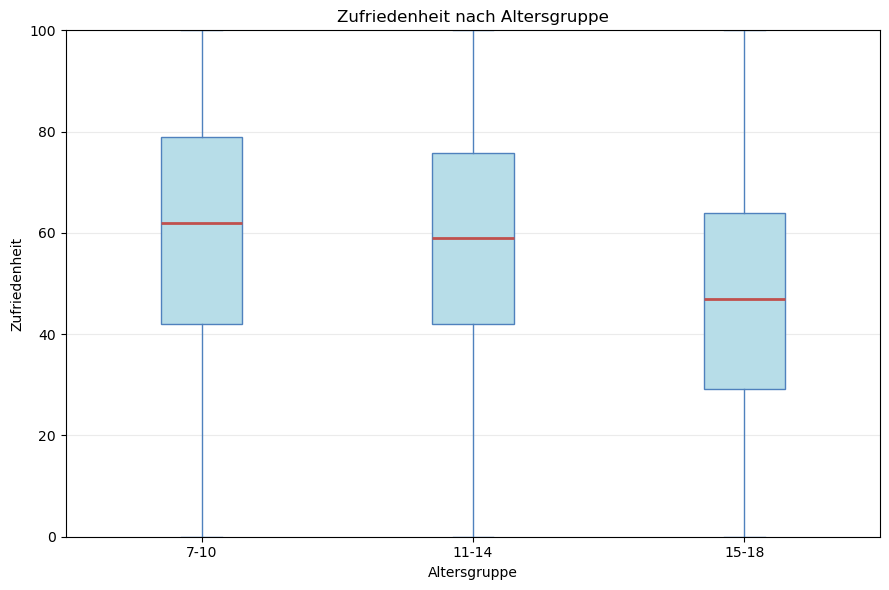

           count       mean        std  min    25%   50%    75%    max
age_group                                                             
7-10       500.0  59.604000  25.114870  0.0  42.00  62.0  79.00  100.0
11-14      350.0  58.231429  23.379776  0.0  42.00  59.0  75.75  100.0
15-18      150.0  46.846667  23.554232  0.0  29.25  47.0  64.00  100.0


In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# 1. Daten laden
with open("personas2.json", "r", encoding="utf-8") as f:
    population = json.load(f)

# 2. Relevante Daten extrahieren
rows = []

for p in population:
    age = p["identity"]["age"]
    satisfaction = p["satisfaction"]

    # Altersgruppe bestimmen
    if 7 <= age <= 10:
        age_group = "7-10"
    elif 11 <= age <= 14:
        age_group = "11-14"
    else:
        age_group = "15-18"

    rows.append({
        "age_group": age_group,
        "satisfaction": satisfaction
    })

df = pd.DataFrame(rows)

# 3. Reihenfolge der Altersgruppen festlegen
age_order = ["7-10", "11-14", "15-18"]

# 4. Daten für den Boxplot vorbereiten
data_to_plot = [
    df[df["age_group"] == group]["satisfaction"]
    for group in age_order
]

# 5. Boxplot erstellen
plt.figure(figsize=(9, 6))

plt.boxplot(
    data_to_plot,
    labels=age_order,
    patch_artist=True,
    boxprops=dict(facecolor="#B7DDE8", color="#4F81BD"),
    medianprops=dict(color="#C0504D", linewidth=2),
    whiskerprops=dict(color="#4F81BD"),
    capprops=dict(color="#4F81BD"),
    flierprops=dict(
        marker="o",
        markerfacecolor="#F4CCCC",
        markeredgecolor="#C0504D",
        alpha=0.7
    )
)

# 6. Diagramm beschriften
plt.ylim(0, 100)
plt.xlabel("Altersgruppe")
plt.ylabel("Zufriedenheit")
plt.title("Zufriedenheit nach Altersgruppe")
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# 7. Zusätzlich: Kennzahlen ausgeben
summary = df.groupby("age_group")["satisfaction"].describe()
summary = summary.loc[age_order]

print(summary)